# Chapter 4: Regression and Prediction

This notebook reproduces the Python code from Chapter 4 of *Practical Statistics for Data Scientists* (2nd Edition) by Peter Bruce, Andrew Bruce, and Peter Gedeck.

The chapter covers linear regression, one of the most common tools in statistics and data science. It discusses simple and multiple linear regression, model assessment and selection, weighted regression, prediction intervals, factor (categorical) variables, interpreting coefficients, regression diagnostics, and nonlinear extensions such as polynomial regression, splines, and generalized additive models (GAM).

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import linregress

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from dmba import stepwise_selection, AIC_score

import seaborn as sns
import matplotlib.pyplot as plt

DATA = Path('data')

## 1. Simple Linear Regression

**Simple linear regression** models the relationship between the magnitude of one variable and that of a second. For example, as X increases, Y also increases (or decreases).

The regression equation is:

Y = b0 + b1·X

- **Response (Y)**: the variable we are trying to predict (also called the dependent variable or target).
- **Independent variable (X)**: the variable used to predict the response (also called the predictor or feature).
- **Intercept (b0)**: the predicted value of Y when X = 0.
- **Regression coefficient / slope (b1)**: the change in Y for a one-unit change in X.
- **Fitted values (Ŷ)**: the predictions from the regression line.
- **Residuals (errors)**: the differences between the observed values and the fitted values.
- **Least squares**: the method of fitting the line by minimizing the sum of squared residuals (RSS).

Regression can be used for **prediction** (forecasting new outcomes) or for **explanation** (understanding the relationship between variables). Correlation measures the strength of a relationship, while regression quantifies its nature.

The example uses data on workers' exposure to cotton dust (years) and their lung capacity (PEFR, peak expiratory flow rate).

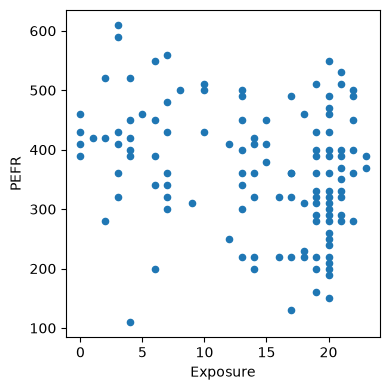

In [4]:
lung = pd.read_csv(DATA / 'LungDisease.csv')

ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
plt.tight_layout()
plt.show()

In [5]:
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


The negative coefficient means that each additional year of exposure to cotton dust is associated with a decrease in lung capacity (PEFR). The intercept is the predicted PEFR for a worker with zero years of exposure.

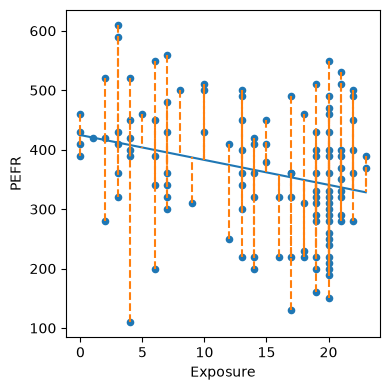

In [6]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung.Exposure, fitted)
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted):
    ax.plot((x, x), (yactual, yfitted), '--', color='C1')
plt.tight_layout()
plt.show()

The line shows the fitted regression line, and the dashed vertical lines show the residuals: the distance between each observed value and the line. Least squares chooses the line that makes the sum of the squared residuals as small as possible.

## 2. Multiple Linear Regression

When there are multiple predictors, the equation is extended:

Y = b0 + b1·X1 + b2·X2 + ... + bp·Xp

Each coefficient is interpreted as the change in Y for a one-unit change in that predictor, **holding all other predictors constant**.

The example uses house sales data from King County, Washington, predicting the adjusted sale price from the size of the house, size of the lot, number of bathrooms and bedrooms, and building grade.

In [7]:
house = pd.read_csv(DATA / 'house_sales.csv', sep='\t')

subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
house[subset].head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7


In [8]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, house_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240754
 SqFtLot: -0.06046682065306008
 Bathrooms: -19442.840398321146
 Bedrooms: -47769.955185214094
 BldgGrade: 106106.9630789811


For example, the coefficient for SqFtTotLiving shows how much the predicted sale price increases for each additional square foot of living space, assuming the other variables stay the same.

### 2.1 Assessing the Model

- **RMSE (root mean squared error)**: the square root of the average squared error. It measures the overall accuracy of the model, in the same units as the outcome.
- **RSE (residual standard error)**: similar to RMSE but adjusted for the number of predictors (divided by degrees of freedom).
- **R-squared (coefficient of determination)**: the proportion of variance in the outcome explained by the model, ranging from 0 to 1. Adjusted R-squared penalizes adding more predictors.
- **t-statistic and p-value of a coefficient**: measure whether a predictor is statistically significant. A high t-statistic (low p-value) means the predictor is likely useful.

In [9]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


In [10]:
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:38:26   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

The statsmodels summary gives the same coefficients as scikit-learn, plus additional statistics such as the standard error, t-statistic, and p-value of each coefficient, and the R-squared of the model.

### 2.2 Cross-Validation

Metrics like R-squared and p-values are all calculated on the same data used to fit the model (**in-sample** metrics). A better approach is to test the model on data it has not seen, using **cross-validation**:
1. Set aside 1/k of the data as a holdout sample.
2. Train the model on the remaining data.
3. Apply the model to the holdout and record the evaluation metrics.
4. Repeat k times, each time using a different holdout.
5. Average the results.

This is called **k-fold cross-validation**.

### 2.3 Model Selection and Stepwise Regression

Adding more variables does not always make a model better. The principle of **Occam's razor** says that, all else being equal, a simpler model should be preferred.

- **AIC (Akaike's Information Criterion)**: a metric that rewards model fit but penalizes the number of predictors. Lower AIC is better. Related metrics include AICc and BIC.
- **Stepwise regression**: automatically adds or removes predictors one at a time to find the model with the best AIC.
- **Forward selection** starts with no predictors and adds them one by one. **Backward elimination** starts with all predictors and removes them one by one.
- **Penalized regression** (such as ridge and lasso) is a related approach that shrinks coefficients instead of removing variables entirely.

First, a model with many predictors is fit.

In [11]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade',
              'PropertyType', 'NbrLivingUnits', 'SqFtFinBasement', 'YrBuilt',
              'YrRenovated', 'NewConstruction']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X['NewConstruction'] = X['NewConstruction'].astype(int)

house_full = sm.OLS(house[outcome], X.assign(const=1))
results = house_full.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:39:16   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving       

In [12]:
y = house[outcome]

def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(X[variables], y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(y, [y.mean()] * len(y), model, df=1)
    return AIC_score(y, model.predict(X[variables]), model)

best_model, best_variables = stepwise_selection(X.columns, train_model, score_model, verbose=True)

print()
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420158
 BldgGrade: 137159.5602261976
 YrBuilt: -3565.424939249463
 Bedrooms: -51947.38367361413
 Bathrooms: 42396.16452772056
 PropertyType_Townhouse: 84479.16203299937
 SqFtFinBasement: 7.046974967583083
 PropertyType_Single Family: 22912.05518701767


The stepwise procedure keeps adding or removing variables as long as the AIC improves, and stops when no change improves the model. Some variables are dropped because they do not add enough predictive value.

### 2.4 Weighted Regression

**Weighted regression** gives some records more influence than others. It is useful when:
- Some observations were measured with different precision (inverse-variance weighting).
- Each row represents multiple cases, so the weight reflects how many cases it represents.

In the example below, newer sales are given more weight, because they are more relevant for predicting current prices. The weight is the number of years since 2005.

In [13]:
house['Year'] = pd.to_datetime(house['DocumentDate']).dt.year
house['Weight'] = house.Year - 2005

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.Weight)

pd.concat([
    pd.DataFrame({
        'predictor': predictors,
        'house_lm': house_lm.coef_,
        'house_wt': house_wt.coef_,
    }),
    pd.DataFrame({
        'predictor': ['intercept'],
        'house_lm': [house_lm.intercept_],
        'house_wt': [house_wt.intercept_],
    }),
])

,predictor,house_lm,house_wt
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726
0,intercept,-521871.368188,-584189.329446


The coefficients of the weighted model are slightly different from the unweighted model, showing that recent sales have a somewhat different relationship between house features and price.

## 3. Prediction Using Regression

The main purpose of regression in data science is prediction. Two cautions apply:

- **Extrapolation**: a regression model should not be used to predict outside the range of the data it was fit on. The relationship may not hold beyond that range.
- **Uncertainty**: predictions should come with a measure of uncertainty.

Two types of intervals are used:
- **Confidence interval**: the uncertainty around a regression coefficient or around the mean prediction.
- **Prediction interval**: the uncertainty around a single predicted value. It is always wider than the confidence interval, because it includes both the uncertainty of the model and the natural variability of individual data points.

Both intervals can be estimated using formulas or with the bootstrap: resample the data, refit the model, make predictions, and (for prediction intervals) add a randomly sampled residual to each prediction.

## 4. Factor Variables in Regression

**Factor variables** (categorical variables) take a limited number of discrete values. Since regression requires numeric inputs, factor variables must be converted to numbers.

- **Dummy variables (one-hot encoding)**: binary 0/1 variables created for each category.
- **Reference coding**: one category is used as the baseline and left out; the other categories are compared to it. This avoids **multicollinearity**, because including all dummies along with an intercept would make one column redundant.
- **Deviation coding** and **polynomial coding** are alternative coding systems.

The example uses the PropertyType variable, which has three categories.

In [14]:
house.PropertyType.head()

1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
Name: PropertyType, dtype: str

In [15]:
pd.get_dummies(house['PropertyType'], dtype=int).head(6)

,Multiplex,Single Family,Townhouse
1,1,0,0
2,0,1,0
3,0,1,0
4,0,1,0
5,0,1,0
6,0,0,1


In [16]:
pd.get_dummies(house['PropertyType'], drop_first=True, dtype=int).head(6)

,Single Family,Townhouse
1,0,0
2,1,0
3,1,0
4,1,0
5,1,0
6,0,1


With `drop_first=True`, the first category (Multiplex) is used as the reference and is left out. The remaining dummy columns indicate whether the property is a Single Family or Townhouse.

In [17]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade', 'PropertyType']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)

house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])

print(f'Intercept: {house_lm_factor.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, house_lm_factor.coef_):
    print(f' {name}: {coef}')

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.37362892503805
 SqFtLot: -0.07036798136812195
 Bathrooms: -15979.013473415263
 Bedrooms: -50889.73218483014
 BldgGrade: 109416.30516146208
 PropertyType_Single Family: -84678.21629549275
 PropertyType_Townhouse: -115121.97921609186


The coefficients for the PropertyType dummies are interpreted relative to the reference category (Multiplex). For example, the Single Family coefficient is the estimated price difference between a single family home and a multiplex with otherwise identical features.

### 4.1 Factor Variables with Many Levels

Some factor variables have many categories, such as zip codes. Creating a dummy for each would add too many predictors. One solution is to **group** the levels using another variable. Here, zip codes are grouped into five groups based on the median residual from the initial housing model: zip codes where the model tends to underpredict or overpredict prices are grouped together.

In [18]:
pd.DataFrame(house['ZipCode'].value_counts()).transpose()

ZipCode,98038,98103,98042,98115,98117,98052,98034,98033,98059,98074,...,98051,98024,98354,98050,98057,98288,98224,98068,98113,98043
count,788,671,641,620,619,614,575,517,513,502,...,32,31,9,7,4,4,3,1,1,1


In [19]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

residuals_df = pd.DataFrame({
    'ZipCode': house['ZipCode'],
    'residual': house[outcome] - house_lm.predict(house[predictors]),
})

zip_groups = (residuals_df.groupby('ZipCode')['residual']
              .agg(count='count', median_residual='median')
              .reset_index()
              .sort_values('median_residual'))
zip_groups['cum_count'] = np.cumsum(zip_groups['count'])
zip_groups['ZipGroup'] = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=False)

zip_groups.head()

,ZipCode,count,median_residual,cum_count,ZipGroup
36,98057,4,-537321.644462,4,0
27,98043,1,-307661.343614,5,0
46,98092,289,-193569.183599,294,0
23,98038,788,-150066.477035,1082,0
31,98051,32,-142352.869593,1114,0


In [20]:
to_join = zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode')
house = house.join(to_join, on='ZipCode')
house['ZipGroup'] = house['ZipGroup'].astype('category')

house['ZipGroup'].value_counts().sort_index()

ZipGroup
0    4733
1    3602
2    4607
3    4279
4    5466
Name: count, dtype: int64

Each house now has a ZipGroup from 0 to 4, where group 0 contains zip codes where the basic model overpredicts prices the most, and group 4 contains zip codes where it underpredicts the most. This turns a variable with many levels into one with only five.

### 4.2 Ordered Factor Variables

Some factor variables are **ordered**, meaning their categories have a natural order. For example, the building grade (BldgGrade) ranges from low to high quality. Ordered factors can often be treated as numeric variables, which preserves the information in the ordering and avoids creating many dummy variables.

## 5. Interpreting the Regression Equation

In data science, the main goal of regression is usually prediction. But interpreting the coefficients is still useful, and several issues can make interpretation tricky.

### 5.1 Correlated Predictors

When predictors are correlated with each other, the sign and size of their coefficients can be hard to interpret. For example, in the stepwise model, the coefficient for Bedrooms may be negative, implying that adding a bedroom reduces the house value. This happens because Bedrooms is correlated with SqFtTotLiving: for a house of the same size, more bedrooms means smaller rooms.

Below, a model without the size variables shows a positive coefficient for Bedrooms.

In [21]:
print('Stepwise model coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Stepwise model coefficients:
 SqFtTotLiving: 199.2775530420158
 BldgGrade: 137159.5602261976
 YrBuilt: -3565.424939249463
 Bedrooms: -51947.38367361413
 Bathrooms: 42396.16452772056
 PropertyType_Townhouse: 84479.16203299937
 SqFtFinBasement: 7.046974967583083
 PropertyType_Single Family: 22912.05518701767


In [22]:
predictors = ['Bedrooms', 'BldgGrade', 'PropertyType', 'YrBuilt']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)

reduced_lm = LinearRegression()
reduced_lm.fit(X, house[outcome])

print(f'Intercept: {reduced_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, reduced_lm.coef_):
    print(f' {name}: {coef}')

Intercept: 4913973.344
Coefficients:
 Bedrooms: 27150.537230219703
 BldgGrade: 248997.79366212635
 YrBuilt: -3211.7448621551157
 PropertyType_Single Family: -19898.495340501973
 PropertyType_Townhouse: -47355.436873344275


### 5.2 Multicollinearity

**Multicollinearity** is an extreme case of correlated predictors, where one predictor can be expressed as a linear combination of others. Causes include including a variable multiple times by mistake, creating P dummies instead of P - 1, or two variables being nearly perfectly correlated. Multicollinearity makes coefficients unstable and must be addressed, usually by removing redundant variables.

### 5.3 Confounding Variables

A **confounding variable** is an important variable that is missing from the model, which can lead to misleading coefficients. In the house data, location is a key confounder: the earlier models did not include it. Adding ZipGroup changes the coefficients considerably.

In [23]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'ZipGroup']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)

confounding_lm = LinearRegression()
confounding_lm.fit(X, house[outcome])

print(f'Intercept: {confounding_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, confounding_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -666637.469
Coefficients:
 SqFtTotLiving: 210.61266005580134
 SqFtLot: 0.45498713854659023
 Bathrooms: 5928.425640001405
 Bedrooms: -41682.871840744636
 BldgGrade: 98541.18352726007
 PropertyType_Single Family: 19323.625287919374
 PropertyType_Townhouse: -78198.72092762377
 ZipGroup_1: 53317.17330659819
 ZipGroup_2: 116251.58883563553
 ZipGroup_3: 178360.5317879338
 ZipGroup_4: 338408.60185652046


The ZipGroup coefficients are large, confirming that location has a strong effect on house prices. The coefficients of other variables also change, showing how leaving out a confounder can distort the model.

### 5.4 Interactions and Main Effects

- **Main effects**: the individual effect of each predictor on the outcome.
- **Interaction**: when the effect of one predictor depends on the value of another.

For example, the effect of house size on price is likely different in expensive locations than in cheaper ones. This is modeled with an interaction term between SqFtTotLiving and ZipGroup.

In [24]:
model = smf.ols(formula='AdjSalePrice ~ SqFtTotLiving*ZipGroup + SqFtLot + '
                        'Bathrooms + Bedrooms + BldgGrade + PropertyType',
                data=house)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:43:05   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

The interaction terms (SqFtTotLiving:ZipGroup) show that the price per square foot varies across zip code groups: in more expensive locations, each additional square foot adds more to the sale price.

## 6. Regression Diagnostics

Regression diagnostics check whether the model's assumptions hold and whether some records have an unusual effect on the results.

- **Standardized residuals**: residuals divided by their standard error, which makes them comparable across records.
- **Outliers**: records far from the rest of the data, with large standardized residuals.
- **Influential values**: records whose presence or absence substantially changes the regression equation.
- **Leverage (hat values)**: how much influence a single record has on the fit.
- **Cook's distance**: combines leverage and residual size into one measure of influence.
- **Heteroskedasticity**: when the variance of residuals is not constant across the range of predicted values.
- **Partial residual plots**: show how well the model fits the relationship between the outcome and a single predictor.

The examples below fit the house model only for zip code 98105.

### 6.1 Outliers

In [25]:
house_98105 = house.loc[house['ZipCode'] == 98105, :]

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']

house_outlier = sm.OLS(house_98105[outcome], house_98105[predictors].assign(const=1))
result_98105 = house_outlier.fit()
print(result_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          1.69e-103
Time:                        16:43:47   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587

In [26]:
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal
print('Index of most extreme residual:', sresiduals.idxmin())
print('Standardized residual:', sresiduals.min())

Index of most extreme residual: 24333
Standardized residual: -4.3267318040785625


In [27]:
outlier = house_98105.loc[sresiduals.idxmin(), :]
print('AdjSalePrice', outlier[outcome])
print(outlier[predictors])

AdjSalePrice 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


This house has a very large negative residual: its actual sale price is far below what the model predicts. Outliers like this are often caused by data errors or special circumstances (for example, a sale that was not a normal market transaction), and should be investigated.

### 6.2 Influential Values

An influential value is a record whose removal would substantially change the regression. The example below uses simulated data: one point far from the rest pulls the regression line toward itself.

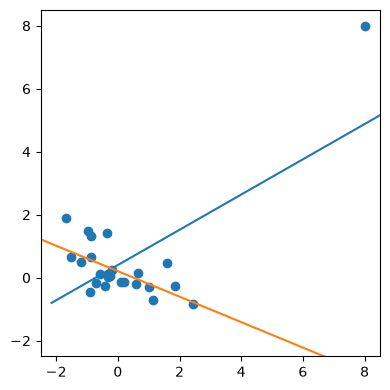

In [28]:
np.random.seed(5)
x = np.random.normal(size=25)
y = -x / 5 + np.random.normal(size=25)
x[0] = 8
y[0] = 8

def abline(slope, intercept, ax):
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x, y)
slope, intercept, _, _, _ = linregress(x, y)
ax.plot(*abline(slope, intercept, ax))
slope, intercept, _, _, _ = linregress(x[1:], y[1:])
ax.plot(*abline(slope, intercept, ax))
ax.set_xlim(-2.5, 8.5)
ax.set_ylim(-2.5, 8.5)
plt.tight_layout()
plt.show()

The two lines show the regression with and without the single extreme point. That one point completely changes the slope, which makes it highly influential.

The influence plot below shows the hat values (leverage) on the x-axis, the standardized residuals on the y-axis, and the size of each bubble proportional to Cook's distance.

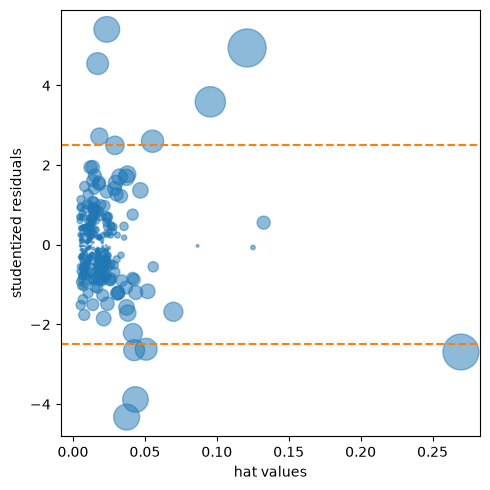

In [29]:
influence = OLSInfluence(result_98105)

fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle='--', color='C1')
ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal,
           s=1000 * np.sqrt(influence.cooks_distance[0]),
           alpha=0.5)
ax.set_xlabel('hat values')
ax.set_ylabel('studentized residuals')
plt.tight_layout()
plt.show()

In [30]:
mask = [dist < .08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]

ols_infl = sm.OLS(house_infl[outcome], house_infl[predictors].assign(const=1))
result_infl = ols_infl.fit()

pd.DataFrame({
    'Original': result_98105.params,
    'Influential removed': result_infl.params,
})

,Original,Influential removed
SqFtTotLiving,209.602346,230.052569
SqFtLot,38.933315,33.141600
Bathrooms,2282.264145,-16131.879785
Bedrooms,-26320.268796,-22887.865318
BldgGrade,130000.099737,114870.559737
const,-772549.862447,-647137.096716


Removing the records with high Cook's distance changes some coefficients noticeably, showing that a few records have a strong effect on the fitted model.

### 6.3 Heteroskedasticity, Non-Normality, and Correlated Errors

Statistical inference in regression assumes residuals are independent, normally distributed, and have constant variance. For prediction, these assumptions matter less, but checking them can reveal ways to improve the model.

The plot below shows the absolute residuals against the predicted values, with a smoothed line.

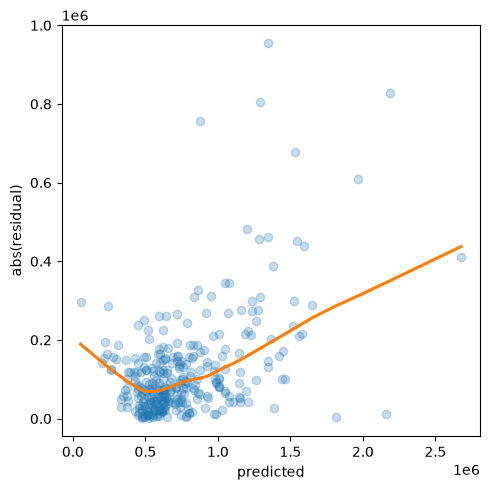

In [31]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid),
            scatter_kws={'alpha': 0.25},
            line_kws={'color': 'C1'},
            lowess=True, ax=ax)
ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')
plt.tight_layout()
plt.show()

The residual size increases for higher predicted values, which is a sign of **heteroskedasticity**: the model is less accurate for more expensive houses.

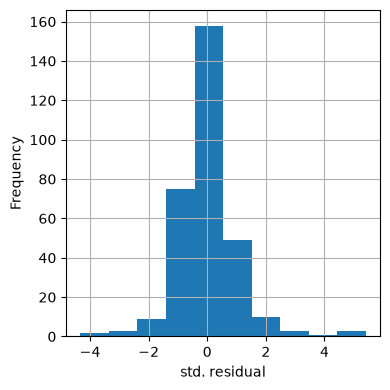

In [32]:
fig, ax = plt.subplots(figsize=(4, 4))
pd.Series(influence.resid_studentized_internal).hist(ax=ax)
ax.set_xlabel('std. residual')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

The histogram of standardized residuals has longer tails than a normal distribution, with some skew, meaning extreme residuals occur more often than expected.

### 6.4 Partial Residual Plots

A **partial residual plot** isolates the relationship between a single predictor and the outcome, taking all other predictors into account. It helps check whether the relationship is really linear.

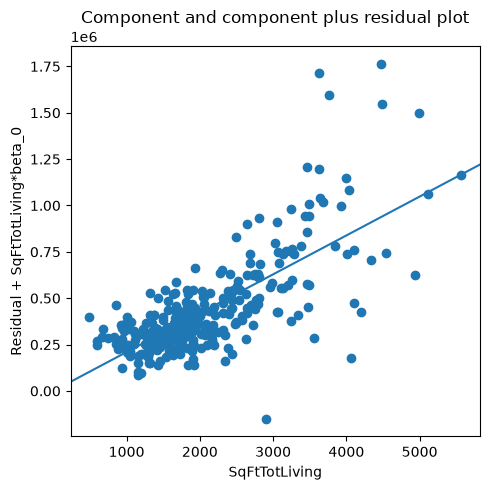

In [33]:
fig, ax = plt.subplots(figsize=(5, 5))
sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)
plt.tight_layout()
plt.show()

The partial residuals suggest that the effect of SqFtTotLiving on price is not perfectly linear: the linear fit tends to underestimate prices for small homes and overestimate them for some larger homes. This motivates the nonlinear models in the next section.

## 7. Polynomial and Spline Regression

The relationship between a predictor and the outcome is not always linear. Several extensions of linear regression can capture nonlinear relationships.

### 7.1 Polynomial Regression

**Polynomial regression** adds polynomial terms (such as squares or cubes) of a predictor to the model. For example, adding SqFtTotLiving² allows the curve to bend.

A helper function is defined first to draw partial residual plots for formula-based models.

In [34]:
def partialResidualPlot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)
    copy_df = df.copy()
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df[c] = 0.0
    feature_prediction = model.predict(copy_df)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params.iloc[0],
    })
    results = results.sort_values(by=['feature'])
    smoothed = sm.nonparametric.lowess(results.ypartial, results.feature, frac=1/3)

    ax.scatter(results.feature, results.ypartial + results.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='gray')
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

In [35]:
model_poly = smf.ols(formula='AdjSalePrice ~ SqFtTotLiving + np.power(SqFtTotLiving, 2) + '
                             'SqFtLot + Bathrooms + Bedrooms + BldgGrade',
                     data=house_98105)
result_poly = model_poly.fit()
print(result_poly.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          9.95e-106
Time:                        16:46:47   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

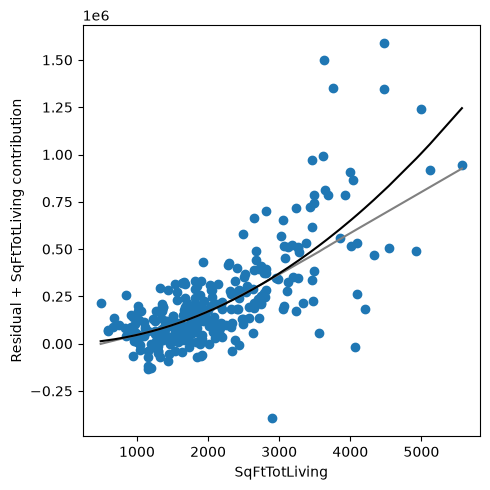

In [36]:
df_98105 = house_98105[predictors + [outcome]]

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_poly, df_98105, outcome, 'SqFtTotLiving', ax)
plt.tight_layout()
plt.show()

The black line (the model's polynomial fit) now follows the curved pattern of the partial residuals more closely than a straight line would.

### 7.2 Splines

Polynomial regression captures only a limited amount of curvature, and high-degree polynomials can behave badly. **Splines** are a more flexible approach: they fit a series of polynomial pieces joined smoothly at fixed points called **knots**. A cubic spline (degree 3) is the most common choice.

In [38]:
formula = ('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + '
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()
print(result_spline.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          7.10e-104
Time:                        16:47:32   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


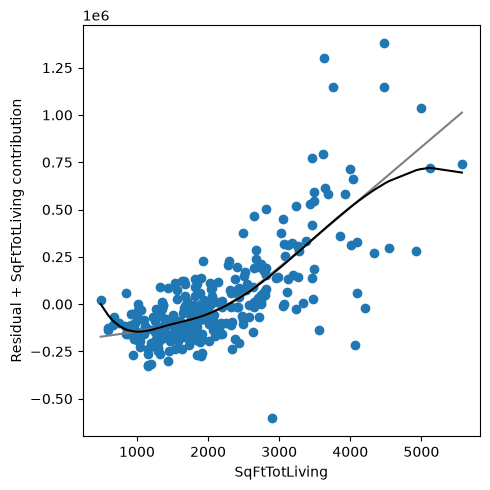

In [39]:
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_spline, df_98105, outcome, 'SqFtTotLiving', ax)
plt.tight_layout()
plt.show()

The spline fit follows the data more flexibly. However, the coefficients of a spline are hard to interpret directly, so visual tools like this plot are needed. Splines can also overfit if too many knots are used.

### 7.3 Generalized Additive Models (GAM)

A **generalized additive model (GAM)** fits a flexible smooth function for each predictor and automatically chooses how much curvature to allow. This avoids having to manually choose polynomial terms or knot positions.

In the model below, SqFtTotLiving is modeled with a smooth spline term `s(0)`, while the other predictors are linear terms `l(1)` to `l(4)`.

In [40]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']

X = house_98105[predictors].values
y = house_98105[outcome]

gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X, y)
gam.summary()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -4213.0332
Number of Samples:                          313 AIC:                                             8443.4209
                                                AICc:                                            8443.9746
                                                GCV:                                      30838885095.1709
                                                Scale:                                         171698.5198
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

C:\Users\PRICILIA APRIANA\AppData\Local\Temp\ipykernel_8960\1566456310.py:8: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


Note: pygam shows a warning that the p-values in this summary are likely underestimated, because the smoothing parameters were estimated from the data. Therefore, these p-values should not be used to judge statistical significance. The GAM is used here mainly to visualize the shape of each predictor's effect, as shown in the next plot.

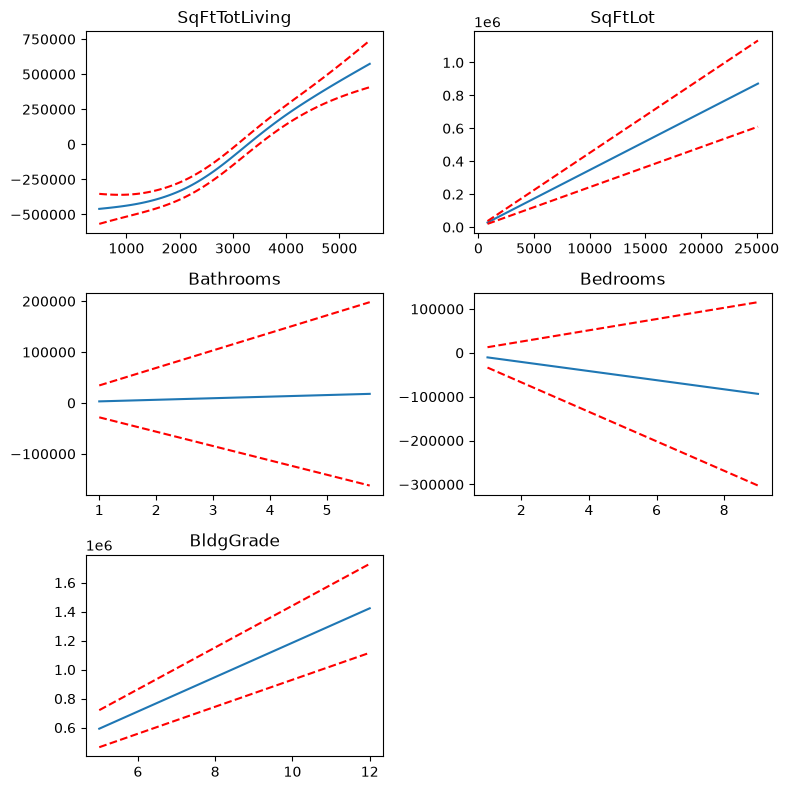

In [41]:
fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)

for i, title in enumerate(predictors):
    ax = axes[i // 2, i % 2]
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax.set_title(title)

axes[2][1].set_visible(False)
plt.tight_layout()
plt.show()

The GAM shows a curved relationship for SqFtTotLiving and straight lines for the other predictors, with dashed lines showing the 95% confidence band. This gives a flexible model while keeping each predictor's effect easy to visualize.

## Summary

This chapter covers regression, the most widely used tool for modeling the relationship between a numeric outcome and one or more predictors.

Key takeaways:
- Simple linear regression fits a line between one predictor and the outcome using least squares. Multiple linear regression extends this to many predictors, each coefficient interpreted while holding the others constant.
- Model performance is measured with RMSE, R-squared, and coefficient t-statistics, but cross-validation gives a more honest estimate of how the model performs on new data.
- Model selection methods such as stepwise regression with AIC help find a simpler model with good predictive power. Weighted regression lets some records count more than others.
- Predictions should not extrapolate beyond the data range, and prediction intervals are wider than confidence intervals.
- Factor variables are converted into dummy variables using reference coding. Variables with many levels can be grouped, and ordered factors can be treated as numeric.
- Correlated predictors, multicollinearity, and confounding variables can make coefficients misleading. Interaction terms capture effects that depend on other variables.
- Regression diagnostics (standardized residuals, Cook's distance, heteroskedasticity checks, partial residual plots) reveal outliers, influential records, and model weaknesses.
- Polynomial regression, splines, and GAMs extend linear regression to capture nonlinear relationships.